In [11]:
# Importing required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report

# Load your dataset
df = pd.read_csv('balanced_dataset.csv')

# 1. EDA
# Check for missing values
print("Missing values in each column:")
print(df.isnull().sum())


Missing values in each column:
Src IP dec             0
Src Port               0
Dst IP dec             0
Dst Port               0
Protocol               0
                      ..
ICMP Code              0
ICMP Type              0
Total TCP Flow Time    0
Label                  0
Attempted Category     0
Length: 89, dtype: int64


In [12]:
df.shape

(285432, 89)

In [13]:
df.head()

,Src IP dec,Src Port,Dst IP dec,Dst Port,Protocol,Timestamp,Flow Duration,Total Fwd Packet,Total Bwd packets,Total Length of Fwd Packet,...,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,ICMP Code,ICMP Type,Total TCP Flow Time,Label,Attempted Category
0,3232238092,45182,1249343060,443,6,00:10.4,5654706,10,9,589,...,125434,5493728.000,0.00,5493728,5493728,-1,-1,5654706,SQL Injection,-1
1,2886729729,58360,3232238130,80,6,10:32.3,6604497,10,6,20,...,416135,6188362.000,0.00,6188362,6188362,-1,-1,6604497,Local File Inclusion (LFI),-1
2,2886729729,36450,3232238130,7435,6,54:16.5,35,1,1,0,...,0,0.000,0.00,0,0,-1,-1,35,Cross-Site Scripting (XSS),-1
3,3232238085,51566,3003077377,80,6,14:56.7,340725,5,5,436,...,0,0.000,0.00,0,0,-1,-1,340725,SQL Injection,-1
4,3232238089,7323,2899905070,80,6,48:25.1,116351256,19,16,877,...,36850,9600636.083,1316834.42,10007599,5424525,-1,-1,116351256,SQL Injection,-1


In [14]:
# Check for duplicates
print(f"Number of duplicate rows: {df.duplicated().sum()}")


Number of duplicate rows: 0


         Src IP dec       Src Port    Dst IP dec       Dst Port  \
count  2.854320e+05  285432.000000  2.854320e+05  285432.000000   
mean   3.001507e+09   47521.200349  3.084412e+09    3079.140643   
std    1.697886e+08   14848.037865  5.539312e+08    8919.006769   
min    1.346109e+08       0.000000  1.686074e+07       0.000000   
25%    2.886730e+09   39492.000000  3.232238e+09      80.000000   
50%    2.886730e+09   52076.500000  3.232238e+09      80.000000   
75%    3.232238e+09   58758.000000  3.232238e+09    1187.000000   
max    3.232238e+09   65535.000000  4.294967e+09   65487.000000   

            Protocol  Flow Duration  Total Fwd Packet  Total Bwd packets  \
count  285432.000000   2.854320e+05     285432.000000      285432.000000   
mean        8.355325   7.276034e+06          7.268989           7.077959   
std         4.518298   2.090415e+07        515.460093         687.367945   
min         0.000000   1.000000e+00          1.000000           0.000000   
25%         6.00

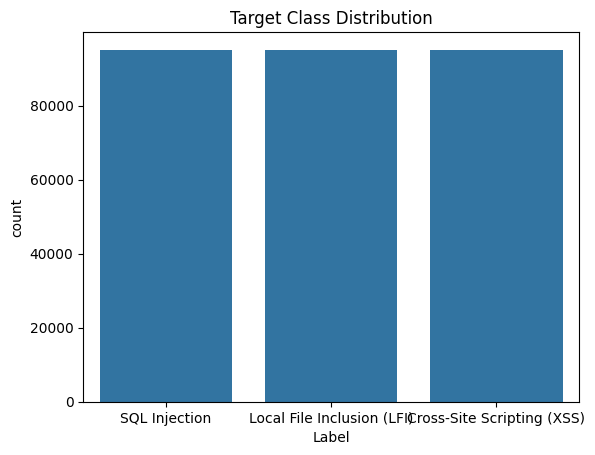

In [15]:
# Basic summary of the dataset
print(df.describe())

# Check the distribution of the target variable
print("Target variable distribution:")
print(df['Label'].value_counts())

# Plot distribution of target variable
sns.countplot(x='Label', data=df)
plt.title('Target Class Distribution')
plt.show()



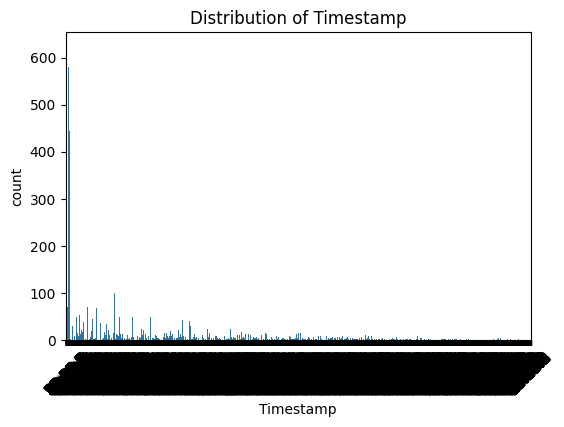

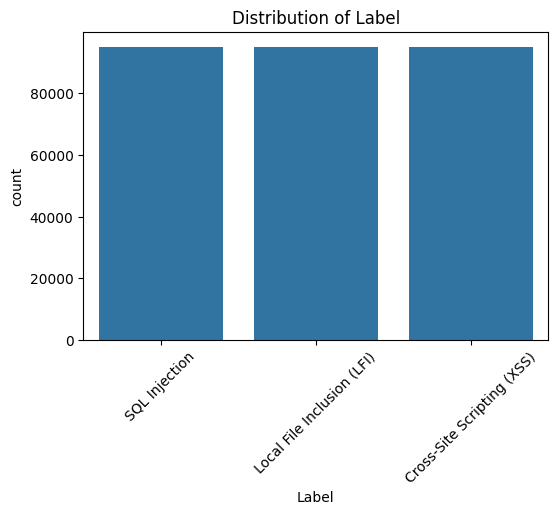

In [16]:
# Countplot for categorical features
categorical_cols = df.select_dtypes(include=['object']).columns
for col in categorical_cols:
    plt.figure(figsize=(6, 4))
    sns.countplot(data=df, x=col)
    plt.title(f"Distribution of {col}")
    plt.xticks(rotation=45)
    plt.show()

In [17]:
# Filter rows where the 'Label' column is 'SQL Injection'
sql_injection_data = df[df['Label'] == 'SQL Injection']

# Select the specified features and get the first 5 rows
selected_features = ['Src IP dec', 'Bwd Packet Length Std', 'Packet Length Max', 'Flow Duration', 'Average Packet Size', 
                     'Bwd Packet Length Max', 'Bwd Packet Length Mean', 'Packet Length Mean', 'Packet Length Std', 
                     'Packet Length Variance', 'Bwd Segment Size Avg', 'Fwd Packet Length Max', 'Fwd Packet Length Mean', 
                     'Flow IAT Max', 'Subflow Bwd Bytes']

# Get the first 5 rows
sql_injection_first_5 = sql_injection_data[selected_features].head(5)

print(sql_injection_first_5)

   Src IP dec  Bwd Packet Length Std  Packet Length Max  Flow Duration  \
0  3232238092             715.672586               1448        5654706   
3  3232238085             384.603692                860         340725   
4  3232238089             254.807509                746      116351256   
7  3232238092             581.410895               1448      116411918   
8  3232238088             635.631855               1460       58708137   

   Average Packet Size  Bwd Packet Length Max  Bwd Packet Length Mean  \
0           262.789474                   1448              489.333333   
3           129.600000                    860              172.000000   
4            67.685714                    746               93.250000   
7           196.791667                   1448              360.913044   
8           235.227273                   1460              417.363636   

   Packet Length Mean  Packet Length Std  Packet Length Variance  \
0          262.789474         532.177036        

In [18]:
# Filter rows where the 'Label' column is 'SQL Injection'
sql_injection_data = df[df['Label'] == 'Local File Inclusion (LFI)']

# Select the specified features and get the first 5 rows
selected_features = ['Src IP dec', 'Bwd Packet Length Std', 'Packet Length Max', 'Flow Duration', 'Average Packet Size', 
                     'Bwd Packet Length Max', 'Bwd Packet Length Mean', 'Packet Length Mean', 'Packet Length Std', 
                     'Packet Length Variance', 'Bwd Segment Size Avg', 'Fwd Packet Length Max', 'Fwd Packet Length Mean', 
                     'Flow IAT Max', 'Subflow Bwd Bytes']

# Get the first 5 rows
sql_injection_first_5 = sql_injection_data[selected_features].head(5)

print(sql_injection_first_5)

    Src IP dec  Bwd Packet Length Std  Packet Length Max  Flow Duration  \
1   2886729729            3125.165196               7215        6604497   
12  2886729729            2190.830322               5840        4183902   
18  2886729729            4129.722297               8760       12126676   
21  2886729729            3771.379721               8675        2146454   
22  2886729729            4456.742645              10220       11445043   

    Average Packet Size  Bwd Packet Length Max  Bwd Packet Length Mean  \
1            725.937500                   7215                 1932.50   
12           829.642857                   5840                 1932.50   
18           967.916667                   8760                 2898.75   
21           967.916667                   8675                 2319.00   
22           893.461538                  10220                 2319.00   

    Packet Length Mean  Packet Length Std  Packet Length Variance  \
1           725.937500        2046.

In [19]:
# Filter rows where the 'Label' column is 'SQL Injection'
sql_injection_data = df[df['Label'] == 'Cross-Site Scripting (XSS)']

# Select the specified features and get the first 5 rows
selected_features = ['Src IP dec', 'Bwd Packet Length Std', 'Packet Length Max', 'Flow Duration', 'Average Packet Size', 
                     'Bwd Packet Length Max', 'Bwd Packet Length Mean', 'Packet Length Mean', 'Packet Length Std', 
                     'Packet Length Variance', 'Bwd Segment Size Avg', 'Fwd Packet Length Max', 'Fwd Packet Length Mean', 
                     'Flow IAT Max', 'Subflow Bwd Bytes']

# Get the first 5 rows
sql_injection_first_5 = sql_injection_data[selected_features].head(5)

print(sql_injection_first_5)

    Src IP dec  Bwd Packet Length Std  Packet Length Max  Flow Duration  \
2   2886729729                    0.0                  0             35   
5   2886729729                    0.0                  0             12   
6   2886729729                    0.0                  0             82   
11  2886729729                    0.0                  0             49   
13  2886729729                    0.0                  0             75   

    Average Packet Size  Bwd Packet Length Max  Bwd Packet Length Mean  \
2                   0.0                      0                     0.0   
5                   0.0                      0                     0.0   
6                   0.0                      0                     0.0   
11                  0.0                      0                     0.0   
13                  0.0                      0                     0.0   

    Packet Length Mean  Packet Length Std  Packet Length Variance  \
2                  0.0             

In [20]:
df['Label'].value_counts()

Label
SQL Injection                 95144
Local File Inclusion (LFI)    95144
Cross-Site Scripting (XSS)    95144
Name: count, dtype: int64

Top 15 features: ['Src IP dec', 'Bwd Packet Length Std', 'Packet Length Max', 'Flow Duration', 'Average Packet Size', 'Bwd Packet Length Max', 'Bwd Packet Length Mean', 'Packet Length Mean', 'Packet Length Std', 'Packet Length Variance', 'Bwd Segment Size Avg', 'Fwd Packet Length Max', 'Fwd Packet Length Mean', 'Flow IAT Max', 'Subflow Bwd Bytes']
Accuracy: 99.76%
Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.99      1.00      3863
           1       1.00      1.00      1.00      3807
           2       0.99      1.00      1.00      3748

    accuracy                           1.00     11418
   macro avg       1.00      1.00      1.00     11418
weighted avg       1.00      1.00      1.00     11418



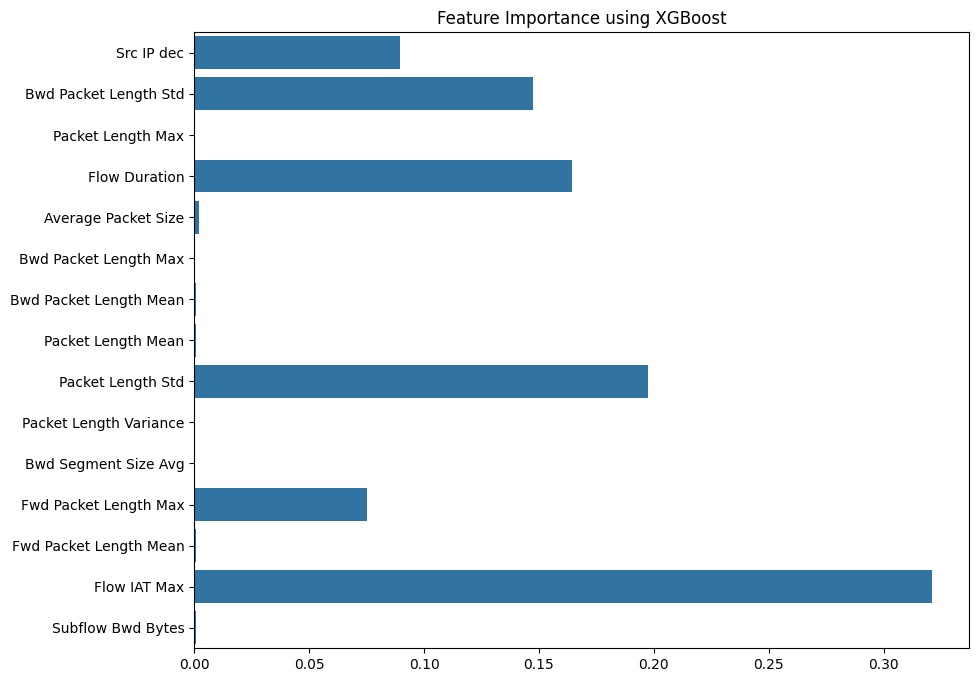

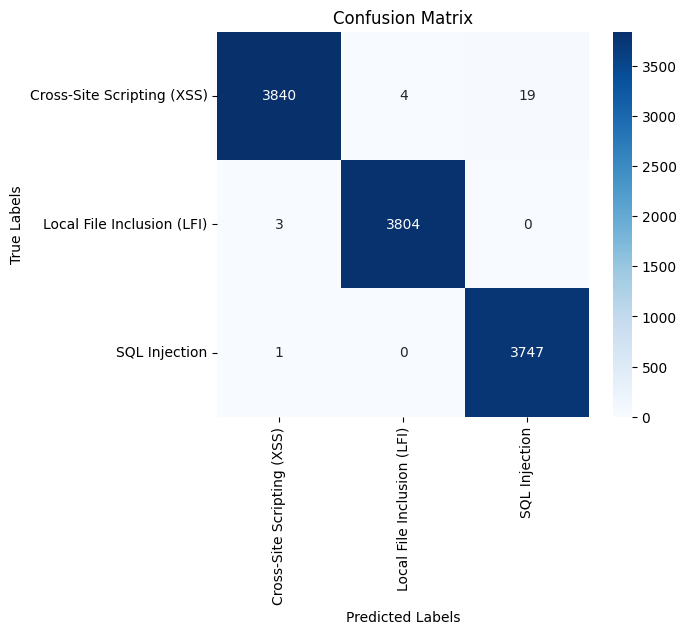

In [22]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
import joblib
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 1. Select 20% of the data randomly
df_partial = df.sample(frac=0.2, random_state=42)

# 2. Preprocessing
X_partial = df_partial.drop('Label', axis=1)
y_partial = df_partial['Label']

# Separate the numeric and non-numeric columns
numeric_cols = X_partial.select_dtypes(include=[np.number]).columns
non_numeric_cols = X_partial.select_dtypes(exclude=[np.number]).columns

# Fill missing values in numeric columns with the median
X_partial[numeric_cols] = X_partial[numeric_cols].fillna(X_partial[numeric_cols].median())

# Handle non-numeric columns
for col in non_numeric_cols:
    if X_partial[col].dtype == 'object':
        X_partial[col] = X_partial[col].fillna(X_partial[col].mode()[0])  # Fill with mode (most frequent value)
    else:
        # For time columns or other types, you might need specific handling
        pass

# Save the median values used for imputation
median_values = X_partial[numeric_cols].median().to_dict()
joblib.dump(median_values, 'median_values.pkl')

# Label encoding for the target
label_encoder_target = LabelEncoder()
y_partial = label_encoder_target.fit_transform(y_partial)
joblib.dump(label_encoder_target, 'label_encoder_target.pkl')   # if needed later

# Encode categorical features and save the encoders
label_encoders = {}
for col in non_numeric_cols:
    le = LabelEncoder()
    X_partial[col] = le.fit_transform(X_partial[col])
    label_encoders[col] = le
joblib.dump(label_encoders, 'label_encoders.pkl')

# Feature selection using Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_partial, y_partial)

# Get top 15 features
importances = rf.feature_importances_
indices = np.argsort(importances)[::-1]
top_features = X_partial.columns[indices[:15]].tolist()
joblib.dump(top_features, 'top_features.pkl')

print("Top 15 features:", top_features)

# Create a new dataset with only the top 15 features
X_selected = X_partial[top_features]

# 3. Train XGBoost Model on the partial data
X_train, X_test, y_train, y_test = train_test_split(X_selected, y_partial, test_size=0.2, random_state=42)

# Initialize and train XGBoost classifier with modified parameters to avoid perfect accuracy
xgb_model = XGBClassifier(
    eval_metric='mlogloss',
    random_state=42,
    max_depth=2,               # Control tree depth to prevent overfitting
    learning_rate=0.1,         # Use a lower learning rate
    n_estimators=10,           # Number of boosting rounds
    subsample=0.8,             # Use 80% of data for each round
    colsample_bytree=0.8,      # Use 80% of features for each round
    early_stopping_rounds=10   # Stop early if no improvement after 10 rounds
)
xgb_model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)

# Predict on the test set
y_pred = xgb_model.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy * 100:.2f}%")

# Detailed classification report
print("Classification Report:")
print(classification_report(y_test, y_pred))

# Plot the feature importance for XGBoost model
plt.figure(figsize=(10, 8))
sns.barplot(x=xgb_model.feature_importances_, y=top_features)
plt.title('Feature Importance using XGBoost')
plt.show()

# 4. Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

# Plot the confusion matrix using seaborn heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=label_encoder_target.classes_, yticklabels=label_encoder_target.classes_)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

In [24]:
df['Label'].value_counts()

Label
SQL Injection                 95144
Local File Inclusion (LFI)    95144
Cross-Site Scripting (XSS)    95144
Name: count, dtype: int64

In [ ]:
import joblib

# Save the trained XGBoost model to a file
joblib.dump(xgb_model, 'xgb_model.pkl')

# To load the model later
# loaded_model = joblib.load('xgb_model.pkl')

['xgb_model.pkl']

[LightGBM] [Warning] early_stopping_round is set=10, early_stopping_rounds=10 will be ignored. Current value: early_stopping_round=10
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000266 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3563
[LightGBM] [Info] Number of data points in the train set: 45668, number of used features: 15
[LightGBM] [Warning] early_stopping_round is set=10, early_stopping_rounds=10 will be ignored. Current value: early_stopping_round=10
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Start training from score -1.090543
[LightGBM] [Info] Start training from score -1.093022
[LightGBM] [Info] Start training from score -1.112415
[LightGBM] [Warning] No further splits with positive gain

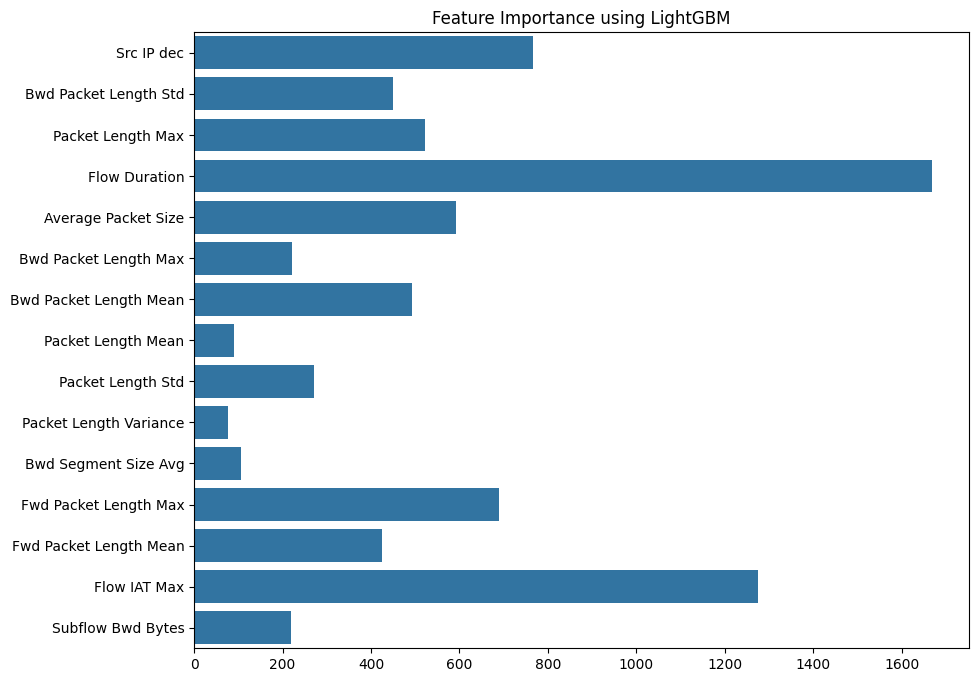

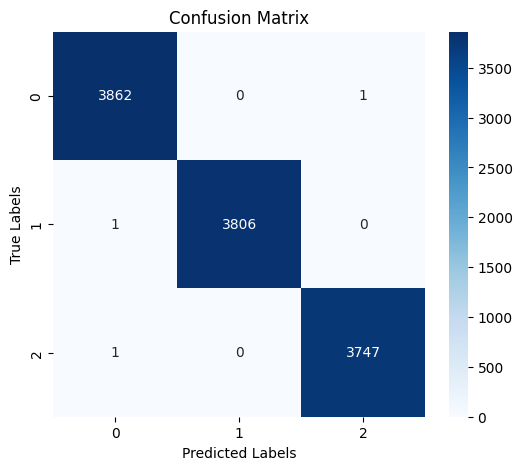

In [ ]:
import lightgbm as lgb
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# Initialize and train LightGBM classifier with modified parameters to prevent 100% accuracy
lgb_model = lgb.LGBMClassifier(
    random_state=42,
    max_depth=6,               # Control tree depth to prevent overfitting
    learning_rate=0.05,        # Lower learning rate to slow down the learning
    n_estimators=100,          # Number of boosting rounds
    subsample=0.8,             # Use 80% of data for each boosting round
    colsample_bytree=0.8,      # Use 80% of features for each boosting round
    min_child_samples=20,      # Minimum number of samples per leaf
    early_stopping_rounds=10   # Stop early if no improvement after 10 rounds
)

# Train the model
lgb_model.fit(X_train, y_train, eval_set=[(X_test, y_test)])

# Predict on the test set
y_pred = lgb_model.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy * 100:.2f}%")

# Detailed classification report
print("Classification Report:")
print(classification_report(y_test, y_pred))

# Plot the feature importance for LightGBM model
plt.figure(figsize=(10, 8))
sns.barplot(x=lgb_model.feature_importances_, y=top_features)
plt.title('Feature Importance using LightGBM')
plt.show()
# 4. Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

# Plot the confusion matrix using seaborn heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=label_encoder_target.classes_, yticklabels=label_encoder_target.classes_)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

Preprocessed input (top 15 features):
   Src IP dec  Bwd Packet Length Std  Packet Length Max  Flow Duration  \
0    19216811                   12.5               1500         123456   

   Average Packet Size  Bwd Packet Length Max  Bwd Packet Length Mean  \
0                  512                   1024                     256   

   Packet Length Mean  Packet Length Std  Packet Length Variance  \
0                 400                100                   10000   

   Bwd Segment Size Avg  Fwd Packet Length Max  Fwd Packet Length Mean  \
0                   128                   1400                     600   

   Flow IAT Max  Subflow Bwd Bytes  
0         50000               2048  
Predicted class: 2
Probabilities: [0.2114736  0.21097866 0.5775477 ]

=== DIAGNOSTIC ===
Type of shap_values: <class 'numpy.ndarray'>
shap_values.shape: (1, 15, 3)
Type of explainer.expected_value: <class 'list'>
Length of expected_value list: 3
Values: [np.float32(0.50552213), np.float32(0.50322586), np.

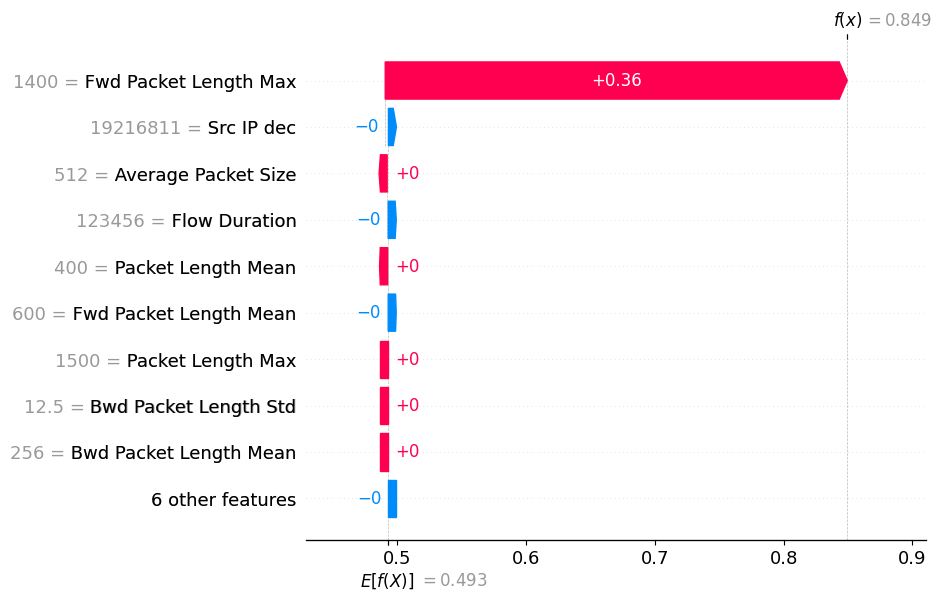

In [ ]:
import joblib
import pandas as pd
import numpy as np
import shap

# -------------------------------
# 1. Load artifacts
# -------------------------------
median_values = joblib.load('median_values.pkl')
top_features = joblib.load('top_features.pkl')
xgb_model = joblib.load('xgb_model.pkl')
# label_encoder_target = joblib.load('label_encoder_target.pkl')  # optional

# -------------------------------
# 2. Preprocessing function (with fillna fix)
# -------------------------------
def preprocess_new_input(new_data_dict, median_values, top_features):
    df_new = pd.DataFrame([new_data_dict])
    all_columns = list(median_values.keys())
    for col in all_columns:
        if col not in df_new.columns:
            df_new[col] = np.nan
    for col in median_values:
        if pd.isna(df_new[col]).any():
            # Fixed: assign back instead of inplace on a slice
            df_new[col] = df_new[col].fillna(median_values[col])
    df_new = df_new[all_columns]
    X_new = df_new[top_features]
    return X_new

# -------------------------------
# 3. New input with all 15 features
# -------------------------------
new_sample = {
    'Src IP dec': 19216811,
    'Bwd Packet Length Std': 12.5,
    'Packet Length Max': 1500,
    'Flow Duration': 123456,
    'Average Packet Size': 512,
    'Bwd Packet Length Max': 1024,
    'Bwd Packet Length Mean': 256,
    'Packet Length Mean': 400,
    'Packet Length Std': 100,
    'Packet Length Variance': 10000,
    'Bwd Segment Size Avg': 128,
    'Fwd Packet Length Max': 1400,
    'Fwd Packet Length Mean': 600,
    'Flow IAT Max': 50000,
    'Subflow Bwd Bytes': 2048
}

X_new = preprocess_new_input(new_sample, median_values, top_features)
print("Preprocessed input (top 15 features):")
print(X_new)

# -------------------------------
# 4. Prediction
# -------------------------------
pred_class = xgb_model.predict(X_new)[0]
pred_proba = xgb_model.predict_proba(X_new)[0]
print(f"Predicted class: {pred_class}")
print(f"Probabilities: {pred_proba}")

# -------------------------------
# 5. SHAP explanation with robust extraction
# -------------------------------
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_new)

# ----- DIAGNOSTIC (remove after you understand the structure) -----
print("\n=== DIAGNOSTIC ===")
print("Type of shap_values:", type(shap_values))
if isinstance(shap_values, list):
    print("Length of shap_values list:", len(shap_values))
    for i, arr in enumerate(shap_values):
        print(f"  shap_values[{i}].shape:", arr.shape)
elif isinstance(shap_values, np.ndarray):
    print("shap_values.shape:", shap_values.shape)
else:
    print("shap_values is neither list nor array:", shap_values)

print("Type of explainer.expected_value:", type(explainer.expected_value))
if isinstance(explainer.expected_value, list):
    print("Length of expected_value list:", len(explainer.expected_value))
    print("Values:", explainer.expected_value)
elif isinstance(explainer.expected_value, np.ndarray):
    print("expected_value.shape:", explainer.expected_value.shape)
else:
    print("expected_value:", explainer.expected_value)
print("=== END DIAGNOSTIC ===\n")

# ----- Robust extraction -----
# Determine how to extract values for the predicted class
if isinstance(shap_values, list) and len(shap_values) == xgb_model.n_classes_:
    # Case A: ideal multi‑class
    shap_vals_for_class = shap_values[pred_class][0]
    base_val = explainer.expected_value[pred_class]
    print("Using per‑class SHAP values (Case A).")

elif isinstance(shap_values, list) and len(shap_values) == 1:
    # Case C: wrapped single array – unwrap and handle as array
    print("Wrapped single array – unwrapping.")
    shap_values = shap_values[0]
    # fall through to array handling below

if isinstance(shap_values, np.ndarray):
    if shap_values.ndim == 2:
        # Case B: single 2D array
        if xgb_model.n_classes_ == 2:
            # Binary model (not your case)
            if pred_class == 1:
                shap_vals_for_class = shap_values[0]
                base_val = explainer.expected_value
            else:
                shap_vals_for_class = -shap_values[0]
                base_val = -explainer.expected_value
            print("Binary model – adjusted SHAP values.")
        else:
            # Multi‑class with single array – recreate explainer with probability output
            print("Single SHAP array for multi‑class model. Re‑creating explainer with model_output='probability'.")
            explainer = shap.TreeExplainer(xgb_model, model_output='probability')
            shap_values = explainer.shap_values(X_new)
            if isinstance(shap_values, list) and len(shap_values) == xgb_model.n_classes_:
                shap_vals_for_class = shap_values[pred_class][0]
                base_val = explainer.expected_value[pred_class]
            else:
                raise RuntimeError("Still cannot obtain per‑class SHAP values. Check SHAP and XGBoost versions.")
    elif shap_values.ndim == 3:
        # Case D: 3D array – shape (n_samples, n_features, n_classes)
        shap_vals_for_class = shap_values[0, :, pred_class]  # shape (n_features,)
        # expected_value may be list or scalar
        if isinstance(explainer.expected_value, list) and len(explainer.expected_value) == xgb_model.n_classes_:
            base_val = explainer.expected_value[pred_class]
        else:
            base_val = explainer.expected_value  # fallback
        print("Using 3D SHAP array (Case D).")
    else:
        raise ValueError(f"Unexpected ndim: {shap_values.ndim}")
else:
    raise ValueError(f"Unexpected shap_values type after handling: {type(shap_values)}")

# Create Explanation object
explanation = shap.Explanation(
    values=shap_vals_for_class,
    base_values=base_val,
    data=X_new.iloc[0].values,
    feature_names=top_features
)

# Waterfall plot
shap.waterfall_plot(explanation)

Accuracy: 99.88%
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      3863
           1       1.00      1.00      1.00      3807
           2       1.00      1.00      1.00      3748

    accuracy                           1.00     11418
   macro avg       1.00      1.00      1.00     11418
weighted avg       1.00      1.00      1.00     11418



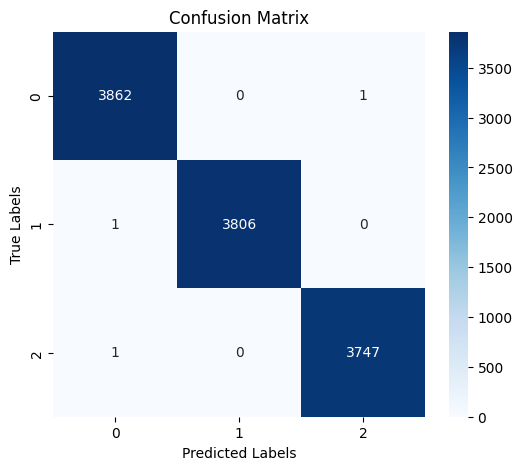

In [ ]:
# Initialize and train Random Forest classifier
rf_model = RandomForestClassifier(
    n_estimators=100,          # Number of trees in the forest
    max_depth=6,               # Maximum depth of the trees
    random_state=42,           # Ensuring reproducibility
    min_samples_split=10,      # Minimum samples required to split a node
    min_samples_leaf=5         # Minimum samples required at a leaf node
)

# Train the model
rf_model.fit(X_train, y_train)

# Predict on the test set
y_pred = rf_model.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy * 100:.2f}%")

# Detailed classification report
print("Classification Report:")
print(classification_report(y_test, y_pred))
# Plot the confusion matrix using seaborn heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=label_encoder_target.classes_, yticklabels=label_encoder_target.classes_)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

C:\Users\1174\AppData\Roaming\Python\Python313\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
C:\Users\1174\AppData\Roaming\Python\Python313\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modul

Accuracy: 99.99%
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      3863
           1       1.00      1.00      1.00      3807
           2       1.00      1.00      1.00      3748

    accuracy                           1.00     11418
   macro avg       1.00      1.00      1.00     11418
weighted avg       1.00      1.00      1.00     11418



C:\Users\1174\AppData\Roaming\Python\Python313\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


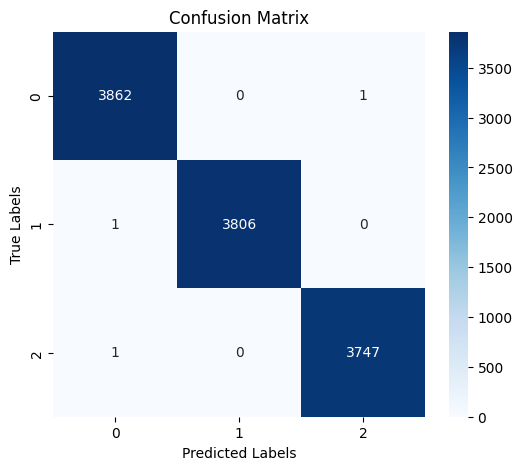

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report
# Define base models for stacking
base_learners = [
    ('rf', RandomForestClassifier(n_estimators=100, random_state=42)),
    ('xgb', XGBClassifier(eval_metric='mlogloss', random_state=42)),
    ('lr', LogisticRegression(random_state=42))
]

# Meta-classifier (Logistic Regression)
meta_learner = LogisticRegression(random_state=42)

# Initialize Stacking Classifier with base models and meta-classifier
stacking_model = StackingClassifier(estimators=base_learners, final_estimator=meta_learner)

# Train the Stacking Classifier
stacking_model.fit(X_train, y_train)

# Predict on the test set
y_pred = stacking_model.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy * 100:.2f}%")

# Detailed classification report
print("Classification Report:")
print(classification_report(y_test, y_pred))
# Plot the confusion matrix using seaborn heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=label_encoder_target.classes_, yticklabels=label_encoder_target.classes_)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()


In [26]:
import pandas as pd
import joblib
import numpy as np

# Load the saved label encoders and model
label_encoder_target = joblib.load('label_encoder_target.pkl')  # LabelEncoder for the target
label_encoders = joblib.load('label_encoders.pkl')  # LabelEncoders for categorical features
xgb_model = joblib.load('xgb_model.pkl')  # Trained XGBoost model

# Input data (raw features)
input_data = [3232238092, 715.672586, 1448, 5654706, 262.789474, 1448, 489.333333, 262.789474, 
              532.177036, 283212.39770, 489.333333, 342, 58.900000, 5493728, 231]

# Convert input to a DataFrame for preprocessing
input_df = pd.DataFrame([input_data], columns=['Src IP dec', 'Bwd Packet Length Std', 'Packet Length Max', 
                                               'Flow Duration', 'Average Packet Size', 'Bwd Packet Length Max', 
                                               'Bwd Packet Length Mean', 'Packet Length Mean', 'Packet Length Std', 
                                               'Packet Length Variance', 'Bwd Segment Size Avg', 'Fwd Packet Length Max', 
                                               'Fwd Packet Length Mean', 'Flow IAT Max', 'Subflow Bwd Bytes'])

# Apply label encoding to categorical features (if applicable)
categorical_cols = input_df.select_dtypes(include=['object']).columns
for col in categorical_cols:
    le = label_encoders[col]
    input_df[col] = le.transform(input_df[col])

# Make prediction using the loaded model
prediction = xgb_model.predict(input_df)

# Decode the prediction (reverse label encoding)
decoded_prediction = label_encoder_target.inverse_transform(prediction)

print(f"The predicted label is: {decoded_prediction[0]}")

The predicted label is: SQL Injection


In [27]:
import pandas as pd
import joblib
import numpy as np

# Load the saved label encoders and model
label_encoder_target = joblib.load('label_encoder_target.pkl')  # LabelEncoder for the target
label_encoders = joblib.load('label_encoders.pkl')  # LabelEncoders for categorical features
xgb_model = joblib.load('xgb_model.pkl')  # Trained XGBoost model

# Provided input data (raw features)
input_data = [
    2886729729, 3125.165196, 7215, 6604497, 725.937500, 7215, 1932.50, 725.937500,
    2046.285430, 4187284.063, 1932.50, 20, 2.000000, 6188362, 724
]

# Convert input to a DataFrame for preprocessing
input_df = pd.DataFrame([input_data], columns=[
    'Src IP dec', 'Bwd Packet Length Std', 'Packet Length Max', 'Flow Duration',
    'Average Packet Size', 'Bwd Packet Length Max', 'Bwd Packet Length Mean',
    'Packet Length Mean', 'Packet Length Std', 'Packet Length Variance',
    'Bwd Segment Size Avg', 'Fwd Packet Length Max', 'Fwd Packet Length Mean',
    'Flow IAT Max', 'Subflow Bwd Bytes'
])

# Apply label encoding to categorical features (if applicable)
categorical_cols = input_df.select_dtypes(include=['object']).columns
for col in categorical_cols:
    le = label_encoders[col]
    input_df[col] = le.transform(input_df[col])

# Make prediction using the loaded model
prediction = xgb_model.predict(input_df)

# Decode the prediction (reverse label encoding)
decoded_prediction = label_encoder_target.inverse_transform(prediction)

print(f"The predicted label is: {decoded_prediction[0]}")

The predicted label is: Local File Inclusion (LFI)
